# GCC118 – Programação Matemática
## Programação Inteira: por que usar e como modelar
### Profa. Andreza C. Beezão Moreira (DMM/UFLA) · Prof. Mayron César O. Moreira (DCC/UFLA)

Notebook de aula. A dinâmica de cada bloco é sempre a mesma:

**💬 discutimos o problema → 📐 modelamos juntos no quadro → 🧩 vocês implementam → ✅ o notebook confere**

Base teórica: slides *Programação inteira – Modelagem* (Wolsey, 1998; Arenales et al., 2007; Sierksma, 1996; slides do Prof. Celso C. Ribeiro/UFF).

| Bloco | Técnica de modelagem |
|:--|:--|
| 0 | Motivação: por que variáveis inteiras? (e por que arredondar não resolve) |
| 1 | **(i)** Implicações *se–então* (custo fixo, produção condicionada) |
| 2 | **(ii)** Restrições disjuntivas (*big-M*, escalonamento) |
| 3 | **(iii)** Relações lógicas (tabela-verdade, carteira de investimentos) |
| 4 | **(iv)** Representação de valores discretos |
| 5 | **(v)** "Ou exclusivo" e indicadores via Teoria de Variáveis Lógicas (TVL) |
| 6 | **(vi)** Problema da mochila binária |
| 7 | **(vii)** *Bin packing* |

Itens marcados com ⭐ são opcionais/desafio — bons candidatos a corte se o tempo apertar.

**Legenda:**
💬 **Discussão** (perguntas para a turma, antes de qualquer código) ·
📐 **Modelo** (texto recolhido; abrir *depois* da discussão) ·
🧩 **Exercício** (completar os `# TODO`) ·
✅ **Verificação** (confere com o gabarito sem revelar o valor) ·
🔓 **Solução** (célula oculta; no Colab, *Mostrar código*. Rodá-la sobrescreve a versão dos alunos e permite seguir a aula).

> **Dica para o professor:** o notebook inteiro roda com *Executar tudo* mesmo antes de os alunos preencherem os `TODO` — as verificações apenas avisam ⏳ que falta completar.

## ⚙️ Preparação
Usaremos **PuLP 2.9.0** (modelagem) com o solver **CBC**, que já vem junto. A célula abaixo instala essa versão se necessário (se pedir, reinicie a sessão uma vez).

In [1]:
import sys, subprocess, itertools, math, time
import numpy as np
import matplotlib.pyplot as plt

# Este notebook foi escrito para o PuLP 2.9.0 (API estável: lowBound / upBound / cat).
VERSAO = "2.9.0"
try:
    import pulp
    ok = (pulp.__version__ == VERSAO)
except ImportError:
    ok = False
if not ok:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", f"pulp=={VERSAO}"])
    print("✅ PuLP", VERSAO, "instalado.")
    print("🔄 AGORA: menu Ambiente de execução → Reiniciar sessão, e rode esta célula de novo.")
else:
    print("✅ PuLP", pulp.__version__, "pronto.")

✅ PuLP 2.9.0 pronto.


In [2]:
#@title ⚙️ Funções auxiliares (não precisa mexer) { display-mode: "form" }
from contextlib import contextmanager

# ----------------------------------------------------------------------------------
# Gabarito (apenas valores ótimos; os alunos só veem ✅/❌ ao conferir)
# ----------------------------------------------------------------------------------
ESPERADO = {
    "wolsey_lp": 5.098445595854923, "wolsey_ip": 5.0,
    "fabrica": 1875.0, "fabrica_regra": 1375.0,
    "M1": 120.0, "M2": 20.0, "disjuncao": 100.0,
    "1maq": 127.0, "1maq_release": 135.0,
    "investimentos": 21.0, "inv_rel_agregada": 23.714285714285715, "inv_rel_desagregada": 22.5,
    "tubos": 41100.0,
    "ressonancia": 39.0,
    "desconto_50": 500.0, "desconto_75": 750.0, "desconto_90": 800.0, "desconto_130": 1040.0,
    "mochila": 142.0, "mochila_extras": 135.0,
    "binpacking": 6.0,
}

def _solver(**kw):
    return pulp.PULP_CBC_CMD(msg=0, **kw)

def resolver(prob, mostrar=True, variaveis=True, **kw):
    """Resolve `prob` com o CBC, imprime um resumo e devolve o valor ótimo (ou None)."""
    if prob.objective is None:
        if mostrar: print("⏳ Falta definir a função objetivo.")
        return None
    t0 = time.time()
    try:
        prob.solve(_solver(**kw))
    except Exception as e:
        if mostrar: print("⏳ Modelo ainda incompleto:", type(e).__name__)
        return None
    dt = time.time() - t0
    obj = pulp.value(prob.objective) if prob.status == 1 else None
    if mostrar:
        print(f"Status: {pulp.LpStatus[prob.status]}" + (f" | objetivo = {obj:.4f}" if obj is not None else "") + f" | {dt:.2f}s")
        if prob.status == 1 and variaveis:
            for v in prob.variables():
                if v.varValue is not None and abs(v.varValue) > 1e-9:
                    print(f"   {v.name} = {v.varValue:g}")
    return obj

def rodar(construtor, *args, mostrar=True, variaveis=True, solver_kw=None, **kwargs):
    """Constrói o modelo chamando `construtor(*args, **kwargs)` (que devolve `prob` ou `(prob, ...)`) e resolve."""
    try:
        out = construtor(*args, **kwargs)
    except Exception as e:
        if mostrar: print(f"⏳ Modelo incompleto — {type(e).__name__}: {e}")
        return None
    prob = out[0] if isinstance(out, tuple) else out
    return resolver(prob, mostrar=mostrar, variaveis=variaveis, **(solver_kw or {}))

@contextmanager
def relaxado(prob):
    """Dentro do bloco `with`, todas as variáveis viram contínuas (relaxação linear)."""
    vs = prob.variables()
    antigas = [v.cat for v in vs]
    for v in vs: v.cat = pulp.LpContinuous
    try:
        yield prob
    finally:
        for v, c in zip(vs, antigas): v.cat = c

def valor_relaxado(prob):
    """Valor ótimo da relaxação linear de `prob` (o modelo original não é alterado)."""
    if prob.objective is None: return None
    with relaxado(prob):
        try:
            prob.solve(_solver())
            return pulp.value(prob.objective) if prob.status == 1 else None
        except Exception:
            return None

def conferir(chave, obtido, tol=1e-4, dica=""):
    """Compara `obtido` com o gabarito `ESPERADO[chave]` sem revelar o valor."""
    if obtido is None:
        print(f"⏳ [{chave}] ainda sem solução ótima — complete os TODO e rode de novo."); return False
    esperado = ESPERADO[chave]
    ok = abs(obtido - esperado) <= tol * max(1.0, abs(esperado))
    if ok: print(f"✅ [{chave}] correto!")
    else:  print(f"❌ [{chave}] o valor obtido não bate com o gabarito." + (f"\n   💡 {dica}" if dica else ""))
    return ok

def _como_lista(r):
    if r is None: return None
    return list(r) if isinstance(r, (list, tuple)) else [r]

---
# Bloco 0 · Por que programação **inteira**?

Até aqui, nossas variáveis eram contínuas. Dois motivos distintos nos levam às variáveis inteiras:

1. **Natureza do problema** (justificativa de Land & Doig): há *indivisibilidades* — não existe "3,7 voos" nem "6,33 enfermeiras".
2. **Artifício de modelagem**: variáveis binárias nos deixam escrever **lógica** (*se–então*, *ou*, *no máximo k*, custo fixo…) dentro de um modelo linear. *É o foco do resto da aula.*

Primeiro, vamos desfazer uma tentação: *"resolvo como PL e arredondo"*.

## 0.1 Por que não arredondar?
Exemplo do slide (Wolsey, 1998):

$$\max\; x_1 + 0{,}64\,x_2 \quad \text{s.a.}\quad 50x_1 + 31x_2 \le 250,\quad 3x_1 - 2x_2 \ge -4,\quad x_1,x_2\ge 0 \text{ inteiros.}$$

### 💬 Discussão
- Qual a ideia por trás de "resolver o PL e arredondar"? O que ela promete (eficiência do simplex)?
- Sem rodar nada: o ótimo do PL será inteiro? Se não, o arredondamento do ótimo do PL será viável? Será ótimo?

### 🧩 Exercício (aquecimento com PuLP)
Complete o modelo abaixo. A mesma função devolve o PL (`inteiro=False`) ou o PIP (`inteiro=True`).

In [3]:
def modelo_wolsey(inteiro=True):
    cat = pulp.LpInteger if inteiro else pulp.LpContinuous
    prob = pulp.LpProblem("wolsey", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=0, cat=cat)
    x2 = pulp.LpVariable("x2", lowBound=0, cat=cat)
    # TODO: função objetivo   max  1.00*x1 + 0.64*x2
    # TODO: restrição         50*x1 + 31*x2 <= 250
    # TODO: restrição         3*x1 - 2*x2 >= -4
    return prob, x1, x2

In [4]:
# ✅ Verificação
obj_lp = rodar(modelo_wolsey, inteiro=False)
obj_ip = rodar(modelo_wolsey, inteiro=True)
conferir("wolsey_lp", obj_lp); conferir("wolsey_ip", obj_ip)

⏳ Falta definir a função objetivo.
⏳ Falta definir a função objetivo.
⏳ [wolsey_lp] ainda sem solução ótima — complete os TODO e rode de novo.
⏳ [wolsey_ip] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [5]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_wolsey(inteiro=True):
    cat = pulp.LpInteger if inteiro else pulp.LpContinuous
    prob = pulp.LpProblem("wolsey", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=0, cat=cat)
    x2 = pulp.LpVariable("x2", lowBound=0, cat=cat)
    prob += 1.00*x1 + 0.64*x2, "obj"
    prob += 50*x1 + 31*x2 <= 250, "c1"
    prob += 3*x1 - 2*x2 >= -4, "c2"
    return prob, x1, x2

obj_lp = rodar(modelo_wolsey, inteiro=False, mostrar=False)
obj_ip = rodar(modelo_wolsey, inteiro=True, mostrar=False)
conferir("wolsey_lp", obj_lp); conferir("wolsey_ip", obj_ip)

✅ [wolsey_lp] correto!
✅ [wolsey_ip] correto!


True

In [6]:
#@title 📈 Gráfico do exemplo (para projetar) { display-mode: "form" }
def plot_wolsey():
    x1 = np.linspace(0, 6, 400)
    fig, ax = plt.subplots(figsize=(6.8, 5.6))
    verts = np.array([[0, 0], [5, 0], [376/193, 950/193], [0, 2]])
    ax.fill(verts[:, 0], verts[:, 1], alpha=.22, color="tab:blue", label="região viável do PL")
    ax.plot(x1, (250 - 50*x1)/31, "k-", lw=1)
    ax.plot(x1, (3*x1 + 4)/2, "k-", lw=1)
    pts = [(a, b) for a in range(0, 7) for b in range(0, 9) if 50*a + 31*b <= 250 and 3*a - 2*b >= -4]
    ax.scatter(*zip(*pts), c="tab:blue", s=36, label="pontos inteiros viáveis", zorder=3)
    ax.scatter(376/193, 950/193, marker="*", s=260, c="tab:red", zorder=4, label="ótimo do PL ≈ (1,95; 4,92)")
    ax.scatter(2, 5, marker="X", s=130, c="black", zorder=5, label="arredondar → (2, 5): INVIÁVEL")
    ax.scatter(5, 0, marker="*", s=260, c="tab:green", zorder=4, label="ótimo inteiro = (5, 0)")
    ax.set_xlim(-.3, 6.2); ax.set_ylim(-.3, 7)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(loc="upper right", fontsize=8)
    ax.set_title("O ótimo inteiro pode estar longe do ótimo do PL")
    plt.show()

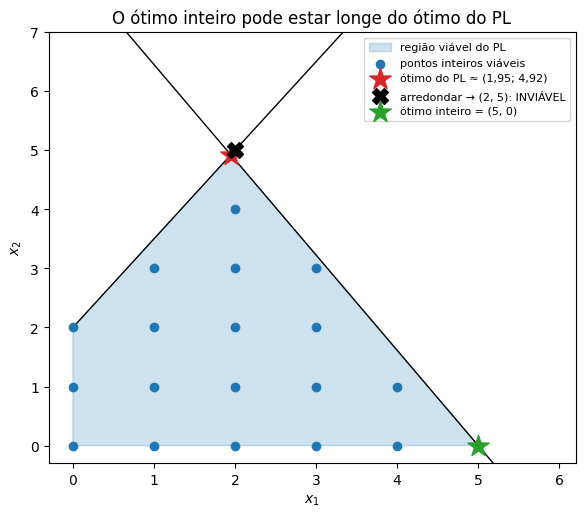

Vizinhos inteiros do ótimo do PL:
  (1,4): INVIÁVEL
  (1,5): INVIÁVEL
  (2,4): viável    valor = 4.56
  (2,5): INVIÁVEL

Ótimo inteiro: (5,0) com valor 5.00  — nenhum vizinho do ótimo do PL chega perto.


In [7]:
plot_wolsey()
x_lp = (376/193, 950/193)
print("Vizinhos inteiros do ótimo do PL:")
for a in (math.floor(x_lp[0]), math.ceil(x_lp[0])):
    for b in (math.floor(x_lp[1]), math.ceil(x_lp[1])):
        viavel = 50*a + 31*b <= 250 and 3*a - 2*b >= -4
        print(f"  ({a},{b}): {'viável  ' if viavel else 'INVIÁVEL'}  valor = {a + 0.64*b:.2f}" if viavel else f"  ({a},{b}): INVIÁVEL")
print("\nÓtimo inteiro: (5,0) com valor 5.00  — nenhum vizinho do ótimo do PL chega perto.")

### 💬 E no caso binário? (slide: "situação ainda mais crítica")
Mochila com 3 itens: $\max 12x_1+7x_2+6x_3$ s.a. $3x_1+2x_2+2x_3\le 4$, $x\in\{0,1\}^3$.
**Antes de rodar:** qual a solução "gulosa" pela razão valor/peso? Ela é ótima?

In [8]:
c = [12, 7, 6]; a = [3, 2, 2]; b = 4
print(" x1 x2 x3 | peso | valor | viável")
melhor = -1
for x in itertools.product([0, 1], repeat=3):
    peso = sum(ai*xi for ai, xi in zip(a, x)); val = sum(ci*xi for ci, xi in zip(c, x))
    ok = peso <= b
    if ok: melhor = max(melhor, val)
    print(f"  {x[0]}  {x[1]}  {x[2]} |  {peso}   |  {val:2d}   | {'sim' if ok else 'não'}")
print("\nRazões c/a:", [round(ci/ai, 2) for ci, ai in zip(c, a)], "→ a gulosa pega o item 1 (valor 12); o ótimo é", melhor, "(itens 2 e 3).")

 x1 x2 x3 | peso | valor | viável
  0  0  0 |  0   |   0   | sim
  0  0  1 |  2   |   6   | sim
  0  1  0 |  2   |   7   | sim
  0  1  1 |  4   |  13   | sim
  1  0  0 |  3   |  12   | sim
  1  0  1 |  5   |  18   | não
  1  1  0 |  5   |  19   | não
  1  1  1 |  7   |  25   | não

Razões c/a: [4.0, 3.5, 3.0] → a gulosa pega o item 1 (valor 12); o ótimo é 13 (itens 2 e 3).


## 0.2 Quando a inteireza é *natural*: escalonamento de enfermeiras
Cada enfermeira trabalha **5 dias consecutivos** e folga 2. Com demanda $d_j$ no dia $j$, minimizar o total contratado:
$x_k$ = nº de enfermeiras que **iniciam** a escala no dia $k$; o dia $j$ é coberto por quem iniciou nos 5 dias anteriores (inclusive $j$).

### 💬 Discussão
O ótimo do PL será inteiro? O que significaria "6,33 enfermeiras"? Se arredondarmos *cada* $x_k$ para cima, ficamos no ótimo?

In [9]:
d = [17, 13, 15, 19, 14, 16, 11]          # demanda de dom..sáb (7 dias)

def modelo_enfermeiras(d, inteiro=True):
    prob = pulp.LpProblem("enfermeiras", pulp.LpMinimize)
    cat = pulp.LpInteger if inteiro else pulp.LpContinuous
    x = [pulp.LpVariable(f"x_{k}", lowBound=0, cat=cat) for k in range(7)]
    prob += pulp.lpSum(x), "total"
    for j in range(7):
        prob += pulp.lpSum(x[k] for k in range(7) if (j - k) % 7 <= 4) >= d[j], f"dia_{j}"
    return prob, x

prob_lp, x_lp_ = modelo_enfermeiras(d, inteiro=False); obj_lp_enf = resolver(prob_lp, variaveis=False)
prob_ip, x_ip_ = modelo_enfermeiras(d, inteiro=True);  obj_ip_enf = resolver(prob_ip, variaveis=False)
print("\nSolução do PL  :", [round(v.varValue, 2) for v in x_lp_])
print("Solução inteira:", [int(round(v.varValue)) for v in x_ip_])
print("Arredondar o PL para cima daria", sum(math.ceil(v.varValue - 1e-9) for v in x_lp_), "enfermeiras (ótimo inteiro =", int(round(obj_ip_enf)), ")")

Status: Optimal | objetivo = 22.3333 | 0.03s
Status: Optimal | objetivo = 23.0000 | 0.02s

Solução do PL  : [1.33, 5.33, 0.0, 7.33, 0.0, 3.33, 5.0]
Solução inteira: [2, 6, 0, 7, 0, 3, 5]
Arredondar o PL para cima daria 25 enfermeiras (ótimo inteiro = 23 )


## 🗺️ Mapa do que vem a seguir
> *Variáveis inteiras como **ferramenta de modelagem*** — a partir daqui, a inteireza **não** vem da natureza do problema, e sim da necessidade de expressar **decisões e lógica**.

Cada bloco ensina uma "receita" de linearização. No fim da aula teremos um **quadro-resumo** com todas elas.

<details>
<summary>🎓 Notas do professor — Bloco 0</summary>

- **Wolsey:** PL ótimo $(376/193,\,950/193)\approx(1{,}95;\,4{,}92)$, valor $\approx 5{,}098$; ótimo inteiro $(5,0)$, valor $5$. Os 4 vizinhos "arredondados" do PL: só $(2,4)$ é viável (valor 4,56) — e o ótimo inteiro está em outra região do poliedro.
- **Mochila 3 itens:** gulosa (razão $c/a$) → item 1, valor 12; ótimo → itens 2 e 3, valor 13.
- **Enfermeiras:** PL = 22,33; PIP = 23. A solução do PL não é única (depende do solver); arredondar para cima costuma dar bem mais que 23.
- Mensagem central: *inteireza por natureza* (enfermeiras, voos) **×** *inteireza como ferramenta de modelagem* (resto da aula).

</details>

---
# Bloco 1 · (i) Implicações *se–então*

Variáveis binárias **sinalizam eventos**: $y=1$ se o evento ocorre, $y=0$ caso contrário. A ferramenta básica é a *restrição de ativação* (*big-M*):

$$x>0 \;\Rightarrow\; y=1 \qquad\Longleftrightarrow\qquad x \le M\,y \quad (M \ge \text{maior valor possível de } x)$$

*(Teorema das variáveis binárias: $\;\delta=0 \Rightarrow f(x)\le 0 \;\Longleftrightarrow\; f(x)-M\delta\le 0$, com $M\ge \max f(x)$.)*

## 1A · Custo fixo (fabricar *exige* pagar a preparação)
Uma fábrica produz **Carrinho (A)**, **Boneca (B)** e **Quebra-cabeça (C)**. Produzir um item *exige* um molde, cujo custo fixo é pago **uma única vez** se o item for produzido — e **zero** se não for. Maximizar o lucro líquido.

In [10]:
produtos    = ["Carrinho", "Boneca", "Quebra-cabeça"]
lucro       = [20, 15, 10]       # R$ por unidade
horas       = [ 3,  1,  2]       # horas de máquina por unidade
plastico    = [ 1,  1,  2]       # kg de plástico por unidade
custo_fixo  = [100, 400, 100]    # R$ (molde)
H, P = 200, 150                  # horas de máquina e kg de plástico disponíveis

### 💬 Discussão
1. Quais são as variáveis de decisão? Só $x_i$ (quantidade) basta para o custo fixo? *(o custo fixo é "tudo ou nada" — não é linear em $x_i$)*
2. Como expressar linearmente *"se $x_i>0$ então $y_i=1$"*?
3. O que impede o solver de deixar $y_i=0$ com $x_i>0$? E nada impede $y_i=1$ com $x_i=0$ — **por que isso não é problema** neste modelo?
4. Que valor dar a $M_i$? *(qual o maior $x_i$ que os recursos permitem?)*

<details>
<summary>📐 Modelo (abrir depois da discussão)</summary>

$x_i\in\mathbb{Z}_+$ = unidades produzidas; $y_i\in\{0,1\}$ = 1 se o molde de $i$ é comprado.

$$\max \sum_i \big(p_i x_i - s_i y_i\big)\quad\text{s.a.}\quad \sum_i h_i x_i\le H,\;\; \sum_i q_i x_i\le P,\;\; x_i \le M_i\,y_i,$$

com $M_i=\min\{H/h_i,\;P/q_i\}$ (o maior $x_i$ viável). Como $s_i>0$ está no objetivo (minimização do custo), $y_i=1$ só "compensa" se $x_i>0$.

</details>

### 🧩 Exercício 1A — complete o objetivo e as restrições de ativação

In [11]:
def modelo_fabrica(M=None, com_regra=False):
    """M=None -> usa o M mais apertado de cada produto; M=número -> mesmo M para todos."""
    n = len(lucro)
    prob = pulp.LpProblem("fabrica", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x_{i}", lowBound=0, cat="Integer") for i in range(n)]
    y = [pulp.LpVariable(f"y_{i}", cat="Binary") for i in range(n)]

    prob += pulp.lpSum(horas[i]*x[i]    for i in range(n)) <= H, "horas"
    prob += pulp.lpSum(plastico[i]*x[i] for i in range(n)) <= P, "plastico"

    # TODO 1: função objetivo (lucro líquido = lucro das unidades - custos fixos dos moldes)

    # TODO 2: restrições de ativação  x_i <= M_i * y_i
    for i in range(n):
        Mi = M if M is not None else min(H/horas[i], P/plastico[i])
        # prob += ...

    return prob, x, y

In [12]:
# ✅ Verificação 1A
obj_fab = rodar(modelo_fabrica)
conferir("fabrica", obj_fab, dica="Lembre: o custo fixo só entra no objetivo multiplicado por y_i.")

⏳ Falta definir a função objetivo.
⏳ [fabrica] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [13]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_fabrica(M=None, com_regra=False):
    n = len(lucro)
    prob = pulp.LpProblem("fabrica", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x_{i}", lowBound=0, cat="Integer") for i in range(n)]
    y = [pulp.LpVariable(f"y_{i}", cat="Binary") for i in range(n)]

    prob += pulp.lpSum(lucro[i]*x[i] - custo_fixo[i]*y[i] for i in range(n)), "lucro_liquido"
    prob += pulp.lpSum(horas[i]*x[i]    for i in range(n)) <= H, "horas"
    prob += pulp.lpSum(plastico[i]*x[i] for i in range(n)) <= P, "plastico"

    for i in range(n):
        Mi = M if M is not None else min(H/horas[i], P/plastico[i])
        prob += x[i] <= Mi*y[i], f"ativa_{i}"

    if com_regra:                       # Exercício 1B: se produzir Boneca (i=1) então Quebra-cabeça (i=2) em lote >= 20
        prob += x[2] >= 20*y[1], "regra_B_implica_C"
    return prob, x, y

obj_fab = rodar(modelo_fabrica, mostrar=False)
conferir("fabrica", obj_fab)

✅ [fabrica] correto!


True

### 🔬 Experimento: o valor de $M$ importa?
Todo $M$ **válido** dá o mesmo ótimo inteiro — mas a **relaxação linear** (que o *branch-and-bound* usa para limitar o ótimo) depende muito dele. Compare o limite superior do PL com diferentes $M$:

In [14]:
ip = rodar(modelo_fabrica, mostrar=False)
if ip is None:
    print("⏳ Complete o exercício 1A (ou rode a solução) para comparar.")
else:
    print(f"Ótimo inteiro: {ip}\n")
    print(f"{'M':>12} | {'relaxação linear':>17} | gap até o ótimo inteiro")
    for M in [10**6, 1000, 200, None]:
        prob, _, _ = modelo_fabrica(M=M)
        rel = valor_relaxado(prob)
        print(f"{('apertado' if M is None else M):>12} | {rel:17.2f} | {rel - ip:8.2f}")
print("\n⚠️ M enorme também causa problemas numéricos: o solver aceita y = 0,00001 como 'zero' (tolerância de integralidade).")

Ótimo inteiro: 1875.0

           M |  relaxação linear | gap até o ótimo inteiro
     1000000 |           2374.95 |   499.95
        1000 |           2322.50 |   447.50
         200 |           2112.50 |   237.50
    apertado |           2004.17 |   129.17

⚠️ M enorme também causa problemas numéricos: o solver aceita y = 0,00001 como 'zero' (tolerância de integralidade).


## 1B · Produção condicionada (*se* o produto 1 é fabricado, *então* o 2 também, em lote mínimo)
Contrato: **se a fábrica produzir Boneca (B), é obrigada a produzir Quebra-cabeça (C) em lote de pelo menos 20 unidades.**

### 💬 Discussão
- Já temos $y_B$ que vale 1 quando $x_B>0$. Como forçar $x_C\ge 20$ **apenas** quando $y_B=1$?
- Slide: se $y=1$ então $x_2\ge m$ → $x_2 \ge m\,y$. Qual a *contrapositiva* ("se não produzir C, então...")? Precisa de outra restrição?
- A regra muda o ótimo? *(Chute antes de rodar.)*

### 🧩 Exercício 1B
Na função `modelo_fabrica` acima (solução ou sua versão), acrescente — dentro de `if com_regra:` — a restrição da regra e confira.

In [15]:
# Edite modelo_fabrica (célula do exercício 1A): inclua   if com_regra:  prob += ...
obj_fab2 = rodar(modelo_fabrica, com_regra=True)
conferir("fabrica_regra", obj_fab2, dica="x_C >= 20 * y_B   (y_B = 1 quando a Boneca é produzida)")

Status: Optimal | objetivo = 1375.0000 | 0.02s
   x_0 = 25
   x_1 = 85
   x_2 = 20
   y_0 = 1
   y_1 = 1
   y_2 = 1
✅ [fabrica_regra] correto!


True

<details>
<summary>🎓 Notas do professor — Bloco 1</summary>

- **Respostas da discussão:** (1) $x_i$ e $y_i$ — o custo fixo é "tudo ou nada", não linear em $x_i$; (2) $x_i\le M_iy_i$; (3) o custo $s_i>0$ no objetivo (maximização) empurra $y_i$ para 0 quando $x_i=0$; (4) $M_i=\min(H/h_i,\,P/q_i)$: $M_A=66{,}7$, $M_B=150$, $M_C=75$.
- **Ótimo 1A:** $x=(25,125,0)$, $y=(1,1,0)$, lucro líquido **1875** (o Quebra-cabeça não compensa o molde). **Com a regra 1B:** $x=(25,85,20)$, $y=(1,1,1)$, **1375**.
- **Experimento do $M$:** relaxação com $M=10^6$ ≈ 2375; $M=1000$ ≈ 2322,5; $M=200$ ≈ 2112,5; $M$ apertado ≈ 2004,2 (ótimo inteiro 1875).
- **Erros típicos:** esquecer $y_i$ no objetivo; usar $M$ minúsculo (corta soluções); escrever $x_C\ge 20$ sem multiplicar por $y_B$ (força $C$ sempre).

</details>

---
# Bloco 2 · (ii) Restrições disjuntivas

Às vezes **só uma** entre várias restrições precisa valer — a região viável deixa de ser convexa:

$$f(x)\le 0 \;\;\text{OU}\;\; g(x)\le 0 \quad\Longrightarrow\quad f(x)\le M_1(1-y),\qquad g(x)\le M_2\,y,\qquad y\in\{0,1\}$$

($y=1$: $f$ está ativa e $g$ é "desligada" por $M_2$; $y=0$: o contrário.)

## 2A · Modos de operação
Uma linha pode operar no **modo A** (energia: $4x_1+2x_2\le 80$) **ou** no **modo B** (insumo: $2x_1+5x_2\le 100$); não precisa respeitar os dois limites ao mesmo tempo. O contrato exige $x_1\ge 10$. Maximizar $2x_1+3x_2$.

### 💬 Discussão
1. Desenhe a região viável. É convexa? **Onde fica o ótimo?** *(chute antes de resolver)*
2. Para que valor de $y$ cada restrição está "ativa"?
3. Qual o menor $M_1$ que **nunca corta** uma solução válida? Dica: $M_1\ge \max\{f(x)\;:\; x\in D,\; g(x)\le 0\}$, onde $D=\{x_1\ge10,\,x_2\ge0\}$ é o domínio. *(Isso é um PL!)*

### 🧩 Exercício 2A-1 — calcule $M_1$ e $M_2$ resolvendo dois PLs

In [16]:
f = lambda x1, x2: 4*x1 + 2*x2 - 80     # modo A:  f(x) <= 0
g = lambda x1, x2: 2*x1 + 5*x2 - 100    # modo B:  g(x) <= 0

def maximizar_sobre(obj, outra):
    """max obj(x)  s.a.  x ∈ D = {x1 >= 10, x2 >= 0}  e  outra(x) <= 0."""
    prob = pulp.LpProblem("M", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=10)
    x2 = pulp.LpVariable("x2", lowBound=0)
    # TODO: objetivo e restrição
    return resolver(prob, mostrar=False)

M1 = maximizar_sobre(f, g)     # maior valor de f quando o modo B está ativo
M2 = maximizar_sobre(g, f)     # maior valor de g quando o modo A está ativo
print("M1 =", M1, "| M2 =", M2)

M1 = None | M2 = None


In [17]:
# ✅ Verificação 2A-1
conferir("M1", M1, dica="M1 = max f(x) sujeito a g(x) <= 0 (e x ∈ D)"); conferir("M2", M2, dica="M2 = max g(x) sujeito a f(x) <= 0 (e x ∈ D)")

⏳ [M1] ainda sem solução ótima — complete os TODO e rode de novo.
⏳ [M2] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [18]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def maximizar_sobre(obj, outra):
    prob = pulp.LpProblem("M", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=10)
    x2 = pulp.LpVariable("x2", lowBound=0)
    prob += obj(x1, x2), "obj"
    prob += outra(x1, x2) <= 0, "outra_ativa"
    return resolver(prob, mostrar=False)

M1 = maximizar_sobre(f, g); M2 = maximizar_sobre(g, f)
print("M1 =", M1, "| M2 =", M2)
conferir("M1", M1); conferir("M2", M2)

M1 = 120.0 | M2 = 20.0
✅ [M1] correto!
✅ [M2] correto!


True

### 🧩 Exercício 2A-2 — escreva o modelo disjuntivo

In [19]:
def modelo_disjuntivo(M1, M2):
    prob = pulp.LpProblem("disjuntivo", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=10)
    x2 = pulp.LpVariable("x2", lowBound=0)
    y  = pulp.LpVariable("y", cat="Binary")          # y = 1  -> modo A ;  y = 0 -> modo B
    prob += 2*x1 + 3*x2, "obj"
    # TODO: f(x) <= M1*(1-y)   e   g(x) <= M2*y
    return prob, x1, x2, y

In [20]:
# ✅ Verificação 2A-2
obj_disj = rodar(modelo_disjuntivo, M1 or 120, M2 or 20)
conferir("disjuncao", obj_disj, dica="f(x) <= M1*(1-y)  e  g(x) <= M2*y")

Status: Unbounded | 0.01s
⏳ [disjuncao] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [21]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_disjuntivo(M1, M2):
    prob = pulp.LpProblem("disjuntivo", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=10)
    x2 = pulp.LpVariable("x2", lowBound=0)
    y  = pulp.LpVariable("y", cat="Binary")
    prob += 2*x1 + 3*x2, "obj"
    prob += f(x1, x2) <= M1*(1 - y), "modoA"
    prob += g(x1, x2) <= M2*y,       "modoB"
    return prob, x1, x2, y

obj_disj = rodar(modelo_disjuntivo, M1 or 120, M2 or 20, mostrar=False)
conferir("disjuncao", obj_disj)

✅ [disjuncao] correto!


True

In [22]:
#@title 📈 Gráficos da disjunção (para projetar) { display-mode: "form" }
def _limite_relaxacao(M1, M2):
    prob = pulp.LpProblem("rel", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=10); x2 = pulp.LpVariable("x2", lowBound=0)
    y = pulp.LpVariable("y", lowBound=0, upBound=1)
    prob += 2*x1 + 3*x2
    prob += 4*x1 + 2*x2 - 80 <= M1*(1 - y)
    prob += 2*x1 + 5*x2 - 100 <= M2*y
    prob.solve(_solver()); return pulp.value(prob.objective)

def plot_disjuncao(configs):
    """Mostra a região viável REAL (azul) e a região da relaxação linear (laranja) para cada (M1, M2)."""
    fig, axs = plt.subplots(1, len(configs), figsize=(5.0*len(configs), 4.5), sharey=True, squeeze=False)
    xs = np.linspace(0, 70, 700); ys = np.linspace(0, 50, 500)
    X1, X2 = np.meshgrid(xs, ys)
    F = 4*X1 + 2*X2 - 80; G = 2*X1 + 5*X2 - 100
    dom = X1 >= 10
    uniao = dom & ((F <= 0) | (G <= 0))
    for ax, (M1, M2) in zip(axs[0], configs):
        rel = dom & (F/M1 + G/M2 <= 1) & (F <= M1) & (G <= M2)
        ax.contourf(X1, X2, rel.astype(int), levels=[.5, 1.5], colors=["#f4a259"], alpha=.55)
        ax.contourf(X1, X2, uniao.astype(int), levels=[.5, 1.5], colors=["#2a6fdb"], alpha=.55)
        ax.scatter([50], [0], marker="*", s=220, c="tab:green", zorder=5)
        ax.set_xlim(0, 70); ax.set_ylim(0, 50); ax.set_xlabel("$x_1$")
        ax.set_title(f"M1={M1:g}, M2={M2:g}\nlimite do PL = {_limite_relaxacao(M1, M2):.1f}  (ótimo inteiro = 100)", fontsize=10)
    axs[0][0].set_ylabel("$x_2$")
    from matplotlib.patches import Patch
    axs[0][-1].legend(handles=[Patch(color="#2a6fdb", alpha=.55, label="região viável real (união)"),
                               Patch(color="#f4a259", alpha=.55, label="região da relaxação com esses M")],
                      loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()

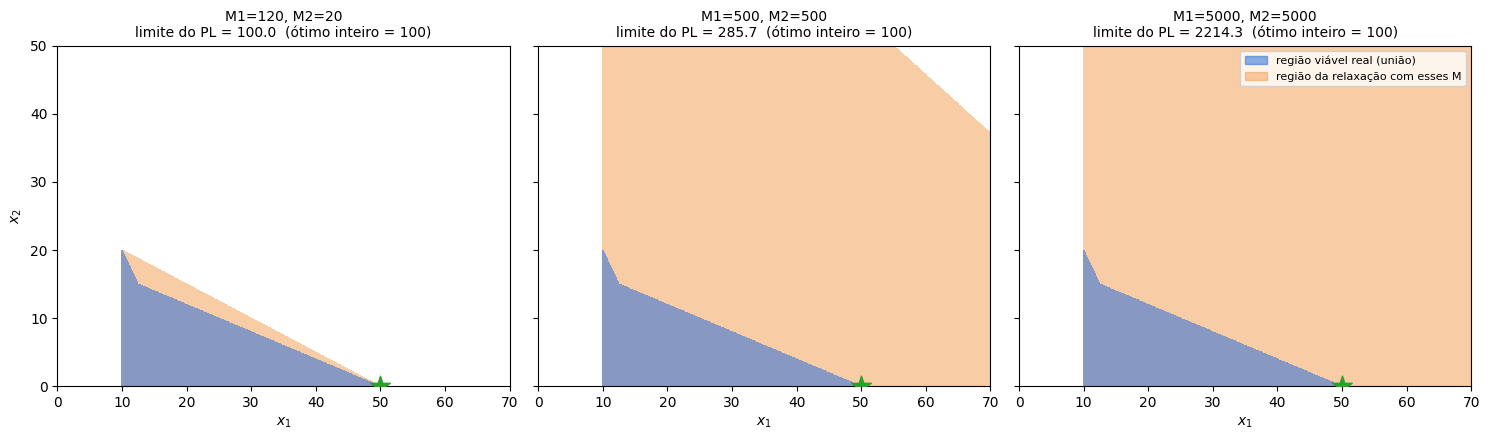

In [23]:
# Região real × região da relaxação: M apertado vs M "folgado"
plot_disjuncao([(120, 20), (500, 500), (5000, 5000)])

### 💬 Leitura do gráfico
O que acontece com a região laranja (relaxação) quando $M$ cresce? Por que isso é ruim para o *branch-and-bound*? *(o limite do PL passa de 100 para ~2200!)*
**Experimente:** o que ocorre se escolhermos um $M$ *menor* que o necessário (use o controle abaixo)?

In [24]:
try:
    from ipywidgets import interact, FloatLogSlider
    @interact(M1=FloatLogSlider(value=120, base=10, min=1, max=4, step=0.02, description="M1"),
              M2=FloatLogSlider(value=20,  base=10, min=0.5, max=4, step=0.02, description="M2"))
    def _(M1, M2):
        plot_disjuncao([(M1, M2)])
except Exception as e:
    print("ipywidgets indisponível aqui — use a figura estática acima.")

interactive(children=(FloatLogSlider(value=120.0, description='M1', min=1.0, step=0.02), FloatLogSlider(value=…

## 2B · Escalonamento em uma máquina: tarefas **não podem se sobrepor**
Seis tarefas $j$ com tempo de processamento $p_j$ e peso $w_j$ numa única máquina. Duas tarefas $j,k$ nunca coexistem: **ou $j$ termina antes de $k$ começar, ou $k$ termina antes de $j$ começar**. Minimizar $\sum_j w_j C_j$ (soma ponderada dos términos).

### 💬 Discussão
1. Variáveis: início $s_j\ge 0$ (contínua). Para cada par $j<k$, qual variável binária representa a ordem?
2. Onde está a disjunção? Escreva as duas restrições "ou" para o par $(j,k)$.
3. Que $M$ vale aqui? *(quanto a diferença de tempos pode valer, no máximo?)*
4. Pergunta de ouro: sem datas de liberação, existe uma regra simples que dê o ótimo? *(Smith / WSPT)*

> Esta é exatamente a ideia por trás das restrições de **ordenação** do flowshop do exercício 4 da lista.

In [25]:
p = [4, 3, 6, 2, 5, 3]      # tempos de processamento
w = [2, 1, 3, 1, 2, 1]      # pesos

def modelo_1maq(p, w, r=None):
    """r = datas de liberação (opcional, ⭐ desafio): a tarefa j só pode iniciar em s_j >= r_j."""
    n = len(p)
    M = sum(p) + (max(r) if r else 0)
    prob = pulp.LpProblem("maquina_unica", pulp.LpMinimize)
    s = [pulp.LpVariable(f"s_{j}", lowBound=0) for j in range(n)]                                   # início
    y = {(j, k): pulp.LpVariable(f"y_{j}_{k}", cat="Binary") for j in range(n) for k in range(j+1, n)}  # y=1: j antes de k

    # TODO 1: objetivo  min sum_j w_j * C_j   com C_j = s_j + p_j
    # TODO 2: para cada par j<k, as duas restrições disjuntivas (use M)
    # TODO 3 (⭐): se r is not None, imponha s_j >= r_j
    return prob, s, y

In [26]:
# ✅ Verificação 2B
obj_1m = rodar(modelo_1maq, p, w, variaveis=False)
conferir("1maq", obj_1m, dica="s_j + p_j <= s_k + M*(1 - y_jk)   e   s_k + p_k <= s_j + M*y_jk")

⏳ Falta definir a função objetivo.
⏳ aq] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [27]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_1maq(p, w, r=None):
    n = len(p)
    M = sum(p) + (max(r) if r else 0)
    prob = pulp.LpProblem("maquina_unica", pulp.LpMinimize)
    s = [pulp.LpVariable(f"s_{j}", lowBound=0) for j in range(n)]
    y = {(j, k): pulp.LpVariable(f"y_{j}_{k}", cat="Binary") for j in range(n) for k in range(j+1, n)}
    prob += pulp.lpSum(w[j]*(s[j] + p[j]) for j in range(n)), "soma_ponderada"
    for (j, k), yjk in y.items():
        prob += s[j] + p[j] <= s[k] + M*(1 - yjk), f"j{j}_antes_k{k}"
        prob += s[k] + p[k] <= s[j] + M*yjk,       f"k{k}_antes_j{j}"
    if r:
        for j in range(n):
            prob += s[j] >= r[j], f"release_{j}"
    return prob, s, y

obj_1m = rodar(modelo_1maq, p, w, mostrar=False)
conferir("1maq", obj_1m)

✅ aq] correto!


True

In [28]:
#@title 🛠️ Auxiliares do escalonamento (Gantt, Smith, força bruta) { display-mode: "form" }
def gantt(s, p, titulo=""):
    n = len(p)
    ordem = sorted(range(n), key=lambda j: s[j].varValue)
    fig, ax = plt.subplots(figsize=(9, 1.9))
    for j in ordem:
        ax.barh(0, p[j], left=s[j].varValue, color=plt.cm.tab10(j % 10), edgecolor="k")
        ax.text(s[j].varValue + p[j]/2, 0, f"J{j+1}", ha="center", va="center", color="w", fontweight="bold")
    ax.set_yticks([]); ax.set_xlabel("tempo"); ax.set_title(titulo)
    plt.tight_layout(); plt.show()
    print("Sequência:", " → ".join(f"J{j+1}" for j in ordem))

def valor_smith(p, w):
    ordem = sorted(range(len(p)), key=lambda j: p[j]/w[j]); t = 0; tot = 0
    for j in ordem:
        t += p[j]; tot += w[j]*t
    return tot, ordem

def forca_bruta_1maq(p, w, r=None):
    n = len(p); r = r or [0]*n; melhor = float("inf")
    for perm in itertools.permutations(range(n)):
        t = 0; tot = 0
        for j in perm:
            t = max(t, r[j]) + p[j]; tot += w[j]*t
        melhor = min(melhor, tot)
    return melhor

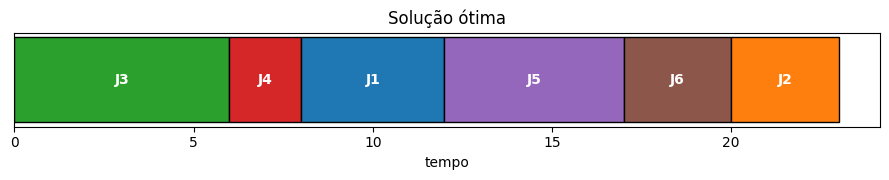

Sequência: J3 → J4 → J1 → J5 → J6 → J2

Regra de Smith (ordenar por p_j/w_j crescente): [1, 3, 4, 5, 2, 6] → Σ w_j C_j = 127


In [29]:
prob_1m, s_1m, _ = modelo_1maq(p, w)
resolver(prob_1m, mostrar=False)
if prob_1m.status == 1:
    gantt(s_1m, p, "Solução ótima")
tot, ordem = valor_smith(p, w)
print(f"\nRegra de Smith (ordenar por p_j/w_j crescente): {[j+1 for j in ordem]} → Σ w_j C_j = {tot}")

### ⭐ Desafio: datas de liberação
Agora a tarefa $j$ só pode começar em $r_j$. A regra de Smith ainda é ótima? Complete o `TODO 3` (se ainda não fez) e compare com a **força bruta** (720 permutações).

In [30]:
r = [5, 0, 12, 0, 0, 0]
obj_rel = rodar(modelo_1maq, p, w, r, variaveis=False)
conferir("1maq_release", obj_rel, dica="Basta acrescentar s_j >= r_j. Note que M precisa cobrir também o maior r_j.")
print("Força bruta:", forca_bruta_1maq(p, w, r), "| Smith ignorando r:", valor_smith(p, w)[0])

Status: Optimal | objetivo = 135.0000 | 0.92s
✅ aq_release] correto!
Força bruta: 135 | Smith ignorando r: 127


<details>
<summary>🎓 Notas do professor — Bloco 2</summary>

- **2A:** $M_1=120$ (em $(50,0)$) e $M_2=20$ (em $(10,20)$) — note que $M_2$ só é tão pequeno porque usamos o domínio $x_1\ge10$. Ótimo inteiro **100** em $(50,0)$ (modo B). Com esses $M$ a relaxação já é **exata** (100); com $M=(120,100)$ dá 116; com $(500,500)$ ≈ 285,7; com $(5000,5000)$ ≈ 2214,3.
- **2B:** ótimo **127** = valor da regra de Smith (ordenar por $p_j/w_j$ crescente; há empates, então há várias sequências ótimas). Com datas $r=(5,0,12,0,0,0)$ o ótimo sobe para **135** (confira com a força bruta).
- **Erros típicos:** trocar $y$ e $1-y$ entre as duas restrições; usar $M$ que não cobre o maior $r_j$; esquecer que a disjunção vale para **cada par** $j<k$.

</details>

---
# Bloco 3 · (iii) Relações lógicas

Associe a cada proposição simples $P_i$ uma variável binária $\delta_i$ ($\delta_i=1\iff P_i$ verdadeira). Proposições compostas viram **restrições lineares sobre os $\delta_i$**.

## 3A · Laboratório: tabela-verdade
Para cada conectivo/regra, escreva **uma restrição linear** (ou várias, combinadas com `and`) tal que ela seja satisfeita **exatamente** nas atribuições em que a proposição é verdadeira. O verificador testa todas as combinações de $\delta$ — como na tabela-verdade do slide.

### 💬 Discussão
- A restrição $\delta_1+\delta_2\ge 1$ representa qual conectivo? E $\delta_1-\delta_2\le 0$? *(vamos pensar no 0/1 de cada caso)*
- Como representar "$P_1\Rightarrow P_2$" sabendo que ela só é falsa quando $P_1=1$ e $P_2=0$?

In [31]:
#@title 🛠️ Verificador de tabela-verdade { display-mode: "form" }
def verificar_logicas(lista):
    """lista de (nome, nvars, regra_logica, restricao_linear). Compara em todas as 2^n atribuições."""
    todas_ok = True
    for nome, n, regra, restr in lista:
        erros = []; pendente = False
        for d in itertools.product([0, 1], repeat=n):
            r = restr(*d)
            if r is None: pendente = True; break
            if bool(r) != bool(regra(*d)): erros.append((d, bool(regra(*d)), bool(r)))
        if pendente:
            print(f"⏳ {nome:<34} (ainda sem restrição)"); todas_ok = False
        elif erros:
            d, t, r = erros[0]; todas_ok = False
            print(f"❌ {nome:<34} {len(erros)} linha(s) da tabela erradas. Ex.: δ={d} → proposição {'V' if t else 'F'}, "
                  f"mas a restrição {'é satisfeita' if r else 'NÃO é satisfeita'}")
        else:
            print(f"✅ {nome:<34} confere em todas as {2**n} linhas")
    return todas_ok

### 🧩 Exercício 3A — preencha as restrições (`lambda ...: None` → sua restrição)

In [32]:
desafios = [
    # (nome,                 nº vars, regra lógica (referência),              restrição linear (VOCÊ escreve))
    ("¬P1  (negação)",           1, lambda a: not a,                          lambda a: a == 0),          # exemplo pronto
    ("P1 ∧ P2  (e)",             2, lambda a, b: a and b,                     lambda a, b: None),
    ("P1 ∨ P2  (ou inclusivo)",  2, lambda a, b: a or b,                      lambda a, b: None),
    ("P1 ▽ P2  (ou exclusivo)",  2, lambda a, b: a != b,                      lambda a, b: None),
    ("P1 ⇒ P2  (implica)",       2, lambda a, b: (not a) or b,                lambda a, b: None),
    ("P1 ⇔ P2  (equivale)",      2, lambda a, b: a == b,                      lambda a, b: None),
    ("P1 ∧ P2 ⇒ P3",             3, lambda a, b, c: (not (a and b)) or c,     lambda a, b, c: None),
    ("P1 ⇒ P2 ∨ P3",             3, lambda a, b, c: (not a) or b or c,        lambda a, b, c: None),
    ("pelo menos 2 de 4",        4, lambda *d: sum(d) >= 2,                   lambda a, b, c, d: None),
    ("exatamente 2 de 4",        4, lambda *d: sum(d) == 2,                   lambda a, b, c, d: None),
    ("no máximo 1 de 4 (excl. mútua)", 4, lambda *d: sum(d) <= 1,             lambda a, b, c, d: None),
]
verificar_logicas(desafios)

✅ ¬P1  (negação)                     confere em todas as 2 linhas
⏳ P1 ∧ P2  (e)                       (ainda sem restrição)
⏳ P1 ∨ P2  (ou inclusivo)            (ainda sem restrição)
⏳ P1 ▽ P2  (ou exclusivo)            (ainda sem restrição)
⏳ P1 ⇒ P2  (implica)                 (ainda sem restrição)
⏳ P1 ⇔ P2  (equivale)                (ainda sem restrição)
⏳ P1 ∧ P2 ⇒ P3                       (ainda sem restrição)
⏳ P1 ⇒ P2 ∨ P3                       (ainda sem restrição)
⏳ pelo menos 2 de 4                  (ainda sem restrição)
⏳ exatamente 2 de 4                  (ainda sem restrição)
⏳ no máximo 1 de 4 (excl. mútua)     (ainda sem restrição)


False

In [33]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
desafios = [
    ("¬P1  (negação)",           1, lambda a: not a,                          lambda a: a == 0),
    ("P1 ∧ P2  (e)",             2, lambda a, b: a and b,                     lambda a, b: a + b == 2),
    ("P1 ∨ P2  (ou inclusivo)",  2, lambda a, b: a or b,                      lambda a, b: a + b >= 1),
    ("P1 ▽ P2  (ou exclusivo)",  2, lambda a, b: a != b,                      lambda a, b: a + b == 1),
    ("P1 ⇒ P2  (implica)",       2, lambda a, b: (not a) or b,                lambda a, b: a - b <= 0),
    ("P1 ⇔ P2  (equivale)",      2, lambda a, b: a == b,                      lambda a, b: a - b == 0),
    ("P1 ∧ P2 ⇒ P3",             3, lambda a, b, c: (not (a and b)) or c,     lambda a, b, c: a + b - c <= 1),
    ("P1 ⇒ P2 ∨ P3",             3, lambda a, b, c: (not a) or b or c,        lambda a, b, c: a - b - c <= 0),
    ("pelo menos 2 de 4",        4, lambda *d: sum(d) >= 2,                   lambda a, b, c, d: a + b + c + d >= 2),
    ("exatamente 2 de 4",        4, lambda *d: sum(d) == 2,                   lambda a, b, c, d: a + b + c + d == 2),
    ("no máximo 1 de 4 (excl. mútua)", 4, lambda *d: sum(d) <= 1,             lambda a, b, c, d: a + b + c + d <= 1),
]
verificar_logicas(desafios)

✅ ¬P1  (negação)                     confere em todas as 2 linhas
✅ P1 ∧ P2  (e)                       confere em todas as 4 linhas
✅ P1 ∨ P2  (ou inclusivo)            confere em todas as 4 linhas
✅ P1 ▽ P2  (ou exclusivo)            confere em todas as 4 linhas
✅ P1 ⇒ P2  (implica)                 confere em todas as 4 linhas
✅ P1 ⇔ P2  (equivale)                confere em todas as 4 linhas
✅ P1 ∧ P2 ⇒ P3                       confere em todas as 8 linhas
✅ P1 ⇒ P2 ∨ P3                       confere em todas as 8 linhas
✅ pelo menos 2 de 4                  confere em todas as 16 linhas
✅ exatamente 2 de 4                  confere em todas as 16 linhas
✅ no máximo 1 de 4 (excl. mútua)     confere em todas as 16 linhas


True

<details>
<summary>📐 Quadro dos conectivos (Sierksma, Tab. 3.3.1)</summary>

| Conectivo | Símbolo | Restrição |
|:--|:-:|:-:|
| Negação | $\neg P_1$ | $\delta_1 = 0$ |
| Conjunção | $P_1\wedge P_2$ | $\delta_1+\delta_2 = 2$ |
| Disjunção inclusiva | $P_1\vee P_2$ | $\delta_1+\delta_2\ge 1$ |
| Disjunção exclusiva | $P_1\triangledown P_2$ | $\delta_1+\delta_2 = 1$ |
| Implicação | $P_1\Rightarrow P_2$ | $\delta_1-\delta_2\le 0$ |
| Equivalência | $P_1\Leftrightarrow P_2$ | $\delta_1-\delta_2=0$ |
| $P_1\wedge\cdots\wedge P_k \Rightarrow P_{k+1}\vee\cdots\vee P_n$ | | $\sum_{i\le k}\delta_i-\sum_{i>k}\delta_i\le k-1$ |
| pelo menos / exatamente / no máximo $k$ de $n$ | | $\sum\delta_i \ge k$ / $=k$ / $\le k$ |

</details>

## 3B · Carteira de investimentos
Cinco investimentos, cada um com retorno e custo. Orçamento de **14**. Escolha a carteira de maior retorno, respeitando as regras:

| | R0 | R1 | R2 | R3 | R4 | R5 |
|:--|:--|:--|:--|:--|:--|:--|
| **Regra** | orçamento | no máximo 3 investimentos | investimento 1 **ou** 2 | **se** 2 **então** 1 | **se** 2, 3 **ou** 4 **então** 1 | **se** 1 **e** 5 **então** 3 |

### 💬 Discussão
- Traduza cada regra para a lógica do bloco 3A. Quais são "inclusivas"? Quais são implicações?
- **Slide "O que é melhor?"**: para R4, compare (a) $x_2+x_3+x_4\le 3x_1$ com (b) $x_2\le x_1,\;x_3\le x_1,\;x_4\le x_1$. As duas são **equivalentes** nos inteiros. Qual é "melhor"? *(pense na relaxação: $x_1=1/3$ e $x_2=x_3=x_4=1$ passa em (a)?)*
- R3 é **redundante** quando usamos (b)? *(sim — o que isso diz sobre a formulação (a)+R3?)*

In [34]:
J = range(1, 6)
retorno = dict(zip(J, [5, 6, 4, 10, 10]))
custo   = dict(zip(J, [4, 6, 5,  3,  5]))
ORC = 14

def modelo_investimentos(desagregada=True):
    prob = pulp.LpProblem("investimentos", pulp.LpMaximize)
    x = {j: pulp.LpVariable(f"x{j}", cat="Binary") for j in J}      # x[j] = 1 se investir em j
    prob += pulp.lpSum(retorno[j]*x[j] for j in J), "retorno"
    prob += pulp.lpSum(custo[j]*x[j] for j in J) <= ORC, "R0_orcamento"
    # TODO R1: no máximo 3 investimentos
    # TODO R2: investimento 1 ou 2
    # TODO R3: se 2 então 1
    # TODO R4: se 2, 3 ou 4 então 1   ->  desagregada=True: uma restrição por investimento;  False: uma restrição agregada
    # TODO R5: se 1 e 5 então 3
    return prob, x

In [35]:
# ✅ Verificação 3B
obj_inv = rodar(modelo_investimentos, desagregada=True)
conferir("investimentos", obj_inv)
obj_inv2 = rodar(modelo_investimentos, desagregada=False, mostrar=False)
conferir("investimentos", obj_inv2, dica="A versão agregada também deve dar o mesmo ótimo inteiro.")

Status: Optimal | objetivo = 26.0000 | 0.02s
   x2 = 1
   x4 = 1
   x5 = 1
❌ [investimentos] o valor obtido não bate com o gabarito.
❌ [investimentos] o valor obtido não bate com o gabarito.
   💡 A versão agregada também deve dar o mesmo ótimo inteiro.


False

In [36]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_investimentos(desagregada=True):
    prob = pulp.LpProblem("investimentos", pulp.LpMaximize)
    x = {j: pulp.LpVariable(f"x{j}", cat="Binary") for j in J}
    prob += pulp.lpSum(retorno[j]*x[j] for j in J), "retorno"
    prob += pulp.lpSum(custo[j]*x[j] for j in J) <= ORC, "R0_orcamento"
    prob += pulp.lpSum(x[j] for j in J) <= 3, "R1_max3"
    prob += x[1] + x[2] >= 1, "R2_1_ou_2"
    prob += x[2] <= x[1], "R3_2_implica_1"
    if desagregada:
        for j in (2, 3, 4):
            prob += x[j] <= x[1], f"R4_{j}_implica_1"
    else:
        prob += x[2] + x[3] + x[4] <= 3*x[1], "R4_agregada"
    prob += x[1] + x[5] - x[3] <= 1, "R5_1e5_implica_3"
    return prob, x

obj_inv = rodar(modelo_investimentos, desagregada=True, mostrar=False); conferir("investimentos", obj_inv)

✅ [investimentos] correto!


True

### 🔬 Experimento: formulação agregada × desagregada — qual tem a relaxação mais forte?

In [37]:
ip  = rodar(modelo_investimentos, desagregada=True, mostrar=False)
rel_agr = valor_relaxado(modelo_investimentos(desagregada=False)[0])
rel_des = valor_relaxado(modelo_investimentos(desagregada=True)[0])
print(f"Ótimo inteiro                 : {ip}")
print(f"Relaxação AGREGADA (x2+x3+x4 ≤ 3x1)    : {rel_agr}")
print(f"Relaxação DESAGREGADA (x_j ≤ x1, j=2,3,4): {rel_des}")
conferir("inv_rel_agregada", rel_agr); conferir("inv_rel_desagregada", rel_des)
print("\n→ Menor limite superior = relaxação mais forte = menos nós no branch-and-bound.\n"
      "  A formulação desagregada tem mais restrições, mas é mais apertada. 'Menos restrições' ≠ 'melhor modelo'.")

Ótimo inteiro                 : 21.0
Relaxação AGREGADA (x2+x3+x4 ≤ 3x1)    : 23.71428569
Relaxação DESAGREGADA (x_j ≤ x1, j=2,3,4): 22.5
✅ [inv_rel_agregada] correto!
✅ [inv_rel_desagregada] correto!

→ Menor limite superior = relaxação mais forte = menos nós no branch-and-bound.
  A formulação desagregada tem mais restrições, mas é mais apertada. 'Menos restrições' ≠ 'melhor modelo'.


<details>
<summary>🎓 Notas do professor — Bloco 3</summary>

- **3B:** ótimo inteiro **21** com os investimentos $\{1,2,4\}$. Sem a regra R5 o ótimo seria 25 com $\{1,4,5\}$ — R5 (junto com o limite de 3 investimentos) é que corta essa solução.
- **Relaxações:** agregada ≈ **23,71**; desagregada = **22,5**; ótimo inteiro 21. Mesma região inteira, relaxações diferentes → "menos restrições ≠ melhor modelo".
- **Erro típico em R5:** escrever $x_1+x_5\le x_3$ (que exige $x_3=1$ mesmo com só um dos dois); o correto é $x_1+x_5-x_3\le 1$.

</details>

---
# Bloco 4 · (iv) Representação de valores discretos

Se $x$ só pode assumir valores de um conjunto discreto $\{v_1,\dots,v_k\}$ (ex.: $\{4,6,8,12,20,24\}$ no slide), use uma binária por valor:

$$x=\sum_{i=1}^{k} v_i\,y_i,\qquad \sum_{i=1}^{k} y_i = 1,\qquad y_i\in\{0,1\}.$$

**Bônus:** qualquer *função* de $x$ também vira linear nos $y_i$: $\;\phi(x)=\sum_i \phi(v_i)\,y_i$ — **mesmo que $\phi$ seja não linear**.

## Problema: escolha de diâmetros de tubulação
Três trechos de tubulação (comprimentos $L_j$) precisam transportar uma vazão mínima $q_j$. Cada trecho usa **um** diâmetro comercial $d\in\{4,6,8,12,20,24\}$ cm. O preço por metro é dado por tabela; a vazão máxima de um tubo é $0{,}5\,d^2$ L/s (**não linear em $d$!**). O estoque de cada diâmetro é limitado (em metros). Minimizar o custo total.

In [38]:
D       = [4, 6, 8, 12, 20, 24]                                 # diâmetros comerciais (cm)
preco   = dict(zip(D, [8, 12, 18, 30, 70, 100]))                # R$/m
vazao   = {d: 0.5*d**2 for d in D}                              # L/s  (função NÃO linear de d)
estoque = dict(zip(D, [500, 500, 500, 150, 250, 300]))          # metros disponíveis
L = [300, 200, 250]                                             # comprimento de cada trecho (m)
q = [ 15,  60, 150]                                             # vazão mínima exigida em cada trecho (L/s)
print("vazão máx. por diâmetro:", vazao)

vazão máx. por diâmetro: {4: 8.0, 6: 18.0, 8: 32.0, 12: 72.0, 20: 200.0, 24: 288.0}


### 💬 Discussão
1. Por que não usar uma variável inteira $d_j$ com $4\le d_j\le 24$? *(os valores 5, 7, 9… não existem)*
2. A vazão cresce com $d^2$. Como o modelo continua **linear**? *(os coeficientes $0{,}5\,v_i^2$ são constantes: o que varia são os $y_{ji}$)*
3. Qual restrição **acopla** os trechos? Sem ela, cada trecho escolheria sozinho o menor diâmetro viável: [6, 12, 20] com custo 27 100. *O que muda com o estoque?*

### 🧩 Exercício 4 — modele a escolha dos diâmetros

In [39]:
def modelo_tubos():
    prob = pulp.LpProblem("tubos", pulp.LpMinimize)
    # y[j, d] = 1 se o trecho j usa o diâmetro d
    y = {(j, d): pulp.LpVariable(f"y_{j}_{d}", cat="Binary") for j in range(3) for d in D}
    # TODO 1: objetivo (custo total = soma de L[j]*preco[d]*y[j,d])
    # TODO 2: cada trecho escolhe exatamente um diâmetro
    # TODO 3: vazão do trecho j >= q[j]   (linear nos y!)
    # TODO 4: metros usados de cada diâmetro <= estoque[d]
    return prob, y

In [40]:
# ✅ Verificação 4
obj_tub = rodar(modelo_tubos, variaveis=False)
conferir("tubos", obj_tub, dica="Lembre do estoque: sem ele o ótimo seria 27100.")

⏳ Falta definir a função objetivo.
⏳ [tubos] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [41]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_tubos():
    prob = pulp.LpProblem("tubos", pulp.LpMinimize)
    y = {(j, d): pulp.LpVariable(f"y_{j}_{d}", cat="Binary") for j in range(3) for d in D}
    prob += pulp.lpSum(L[j]*preco[d]*y[j, d] for j in range(3) for d in D), "custo"
    for j in range(3):
        prob += pulp.lpSum(y[j, d] for d in D) == 1, f"um_diametro_{j}"
        prob += pulp.lpSum(vazao[d]*y[j, d] for d in D) >= q[j], f"vazao_{j}"
    for d in D:
        prob += pulp.lpSum(L[j]*y[j, d] for j in range(3)) <= estoque[d], f"estoque_{d}"
    return prob, y

obj_tub = rodar(modelo_tubos, variaveis=False, mostrar=False)
conferir("tubos", obj_tub)

✅ [tubos] correto!


True

In [42]:
prob_t, y_t = modelo_tubos()
if resolver(prob_t, mostrar=False) is not None:
    for j in range(3):
        d = next(d for d in D if y_t[j, d].varValue > .5)
        print(f"Trecho {j+1}: diâmetro {d} cm  (vazão {vazao[d]:.0f} L/s ≥ {q[j]})")
    print("Custo total: R$", pulp.value(prob_t.objective))

Trecho 1: diâmetro 6 cm  (vazão 18 L/s ≥ 15)
Trecho 2: diâmetro 24 cm  (vazão 288 L/s ≥ 60)
Trecho 3: diâmetro 20 cm  (vazão 200 L/s ≥ 150)
Custo total: R$ 41100.0


> ⭐ **Para pensar:** uma variável *semi-contínua* $x\in\{0\}\cup[\ell,u]$ combina este bloco com o bloco 1. Como modelar? *(dica: $x\le u\,y$ e $x\ge \ell\,y$)*

<details>
<summary>🎓 Notas do professor — Bloco 4</summary>

- **Ótimo:** custo **41 100** com diâmetros $(6,\,24,\,20)$. Sem estoque seria 27 100 com $(6,12,20)$; o estoque do 12 (150 m) não cobre o trecho 2 (200 m), e o do 20 (250 m) só cobre um trecho de 250 m.
- **Ponto-chave:** $0{,}5\,d^2$ é não linear em $d$, mas é **constante** para cada valor discreto — por isso $\sum_d 0{,}5d^2\,y_{jd}$ é linear.

</details>

---
# Bloco 5 · (v) "Ou exclusivo" e indicadores via TVL

Já sabemos: com **proposições simples** (variáveis $\delta_i$), $\;P_1\triangledown P_2\equiv \delta_1+\delta_2=1$.
Mas e quando as proposições são **restrições**: $\;f(x)\le 0 \;\triangledown\; g(x)\le 0$ ("exatamente uma delas vale")?

**Receita da TVL (Sierksma)**

1. Introduza indicadores: $\;\delta_1\leftrightarrow f(x)\le 0,\qquad \delta_2\leftrightarrow g(x)\le 0$.
2. Cada $\leftrightarrow$ é uma **ida** e uma **volta**:
   - **ida** — $\delta_1=1\Rightarrow f(x)\le 0$. Pelo Teorema: $\;f(x)\le M_1(1-\delta_1)$, com $M_1\ge\max f$.
   - **volta** — $\delta_1=0\Rightarrow f(x)>0$. Como o solver não trabalha com "$>$", usamos $f(x)\ge\varepsilon$ ($\varepsilon>0$ = menor "folga" que importa). Pelo Teorema: $\;\varepsilon-f(x)-(\varepsilon-m_1)\,\delta_1\le 0$, com $m_1\le\min f$.
3. Por fim, o "ou exclusivo": $\;\delta_1+\delta_2=1$.

> ⚠️ **Nota de notação:** nos slides, a volta aparece como "$\epsilon-f(x)-m_1\delta_1\le 0$", onde $m_1$ faz o papel de $(\varepsilon-\min f)$. Aqui escrevemos explicitamente $(\varepsilon-m_1)$ com $m_1=\min f$, para não haver ambiguidade.

## 5A · Problema: zona de ressonância
A velocidade $x\in\{0,1,\dots,100\}$ de um motor **não pode ficar na zona de ressonância $40\le x\le 60$**. Há ainda um limite térmico $x\le 55$. Maximizar $x$.
Em termos lógicos: $\;(x\le 60)\;\triangledown\;(x\ge 40)$ — exatamente uma delas é verdadeira (se as duas valem, $x$ está na zona proibida; se nenhuma vale, é impossível).

### 💬 Discussão
- **Sem resolver:** qual o ótimo? *(chute antes de rodar)*
- As regiões $x\le 60$ e $x\ge 40$ se **sobrepõem**. Se usássemos só a "ida" de cada indicador, o modelo proibiria o ponto $x=55$? *(vamos testar!)*

### 🧩 Exercício 5A-1 — escreva a função `indicador` (ida + volta)

In [43]:
#@title 🛠️ Verificador de indicadores { display-mode: "form" }
def verificar_indicador(indicador, f, M, m, eps, dom, nome="δ ⇔ f(x) ≤ 0"):
    """Para todo x do domínio e d ∈ {0,1}: as restrições de `indicador` valem  ⇔  (d = 1  ⇔  f(x) ≤ 0)."""
    erros = []
    for xv in dom:
        fx = f(xv)
        for d in (0, 1):
            r = _como_lista(indicador(fx, d, M, m, eps))
            if r is None or any(c is None for c in r):
                print(f"⏳ {nome}: função `indicador` ainda não implementada (faltam `ida` e/ou `volta`)."); return False
            ok_restr = all(r)
            deveria  = (d == 1) == (fx <= 0)
            if ok_restr != deveria:
                erros.append((xv, d, ok_restr, deveria))
    if erros:
        xv, d, ok_r, dev = erros[0]
        print(f"❌ {nome}: {len(erros)} casos errados. Ex.: x={xv}, δ={d} → f(x)={f(xv)}; "
              f"as restrições {'são satisfeitas' if ok_r else 'NÃO são satisfeitas'}, mas deveriam {'ser' if dev else 'NÃO ser'}.")
        return False
    print(f"✅ {nome}: confere para todos os {len(list(dom))*2} pares (x, δ) testados")
    return True

In [44]:
def indicador(f, d, M, m, eps):
    """Devolve a LISTA de restrições que impõem   d = 1  <=>  f <= 0   .
       f: valor/expressão de f(x);  d: indicador;  M >= max f;  m <= min f;  eps > 0 (folga mínima)."""
    ida   = None    # TODO: d = 1  =>  f <= 0
    volta = None    # TODO: d = 0  =>  f >= eps
    return [ida, volta]

In [45]:
# ✅ Verificação 5A-1: f1(x) = x - 60 (queremos δ1 ⇔ x ≤ 60) e f2(x) = 40 - x (δ2 ⇔ x ≥ 40), x ∈ {0..100}, ε = 1
EPS = 1
verificar_indicador(indicador, lambda x: x - 60, M=40, m=-60, eps=EPS, dom=range(0, 101), nome="δ1 ⇔ x ≤ 60")
verificar_indicador(indicador, lambda x: 40 - x, M=40, m=-60, eps=EPS, dom=range(0, 101), nome="δ2 ⇔ x ≥ 40")

⏳ δ1 ⇔ x ≤ 60: função `indicador` ainda não implementada (faltam `ida` e/ou `volta`).
⏳ δ2 ⇔ x ≥ 40: função `indicador` ainda não implementada (faltam `ida` e/ou `volta`).


False

In [46]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def indicador(f, d, M, m, eps):
    return [f <= M*(1 - d),                    # ida:   d = 1  =>  f <= 0
            eps - f - (eps - m)*d <= 0]        # volta: d = 0  =>  f >= eps

EPS = 1
verificar_indicador(indicador, lambda x: x - 60, M=40, m=-60, eps=EPS, dom=range(0, 101), nome="δ1 ⇔ x ≤ 60")
verificar_indicador(indicador, lambda x: 40 - x, M=40, m=-60, eps=EPS, dom=range(0, 101), nome="δ2 ⇔ x ≥ 40")

✅ δ1 ⇔ x ≤ 60: confere para todos os 202 pares (x, δ) testados
✅ δ2 ⇔ x ≥ 40: confere para todos os 202 pares (x, δ) testados


True

### 🧩 Exercício 5A-2 — use `indicador` no modelo da zona de ressonância
A **mesma** função que testamos com números serve para montar restrições do PuLP (porque `<=` funciona nos dois mundos!).

In [47]:
EPS = 1      # resolução mínima: x é inteiro, então "f > 0" equivale a "f >= 1"

def modelo_ressonancia(com_volta=True):
    prob = pulp.LpProblem("ressonancia", pulp.LpMaximize)
    x  = pulp.LpVariable("x", lowBound=0, upBound=100, cat="Integer")
    d1 = pulp.LpVariable("d1", cat="Binary")      # d1 = 1  <=>  x <= 60
    d2 = pulp.LpVariable("d2", cat="Binary")      # d2 = 1  <=>  x >= 40
    prob += 1*x, "velocidade"
    prob += x <= 55, "limite_termico"

    f1 = x - 60                                   # P1:  f1 <= 0
    f2 = 40 - x                                   # P2:  f2 <= 0
    # TODO 1: limites de f1 e f2 para x em [0, 100]
    # M1, m1 = ..., ...
    # M2, m2 = ..., ...
    # TODO 2: adicione ao modelo as restrições de indicador(f1, d1, ...) e indicador(f2, d2, ...)
    #         (se com_volta=False, use apenas a 1ª restrição de cada lista — a "ida")
    # TODO 3: ou exclusivo -> d1 + d2 == 1
    return prob, x, d1, d2

In [48]:
# ✅ Verificação 5A-2
obj_res = rodar(modelo_ressonancia, com_volta=True)
conferir("ressonancia", obj_res, dica="Confira: com d1+d2=1, o ponto x=55 (e todo x em 40..60) deve ficar PROIBIDO.")

Status: Optimal | objetivo = 55.0000 | 0.02s
   x = 55
❌ [ressonancia] o valor obtido não bate com o gabarito.
   💡 Confira: com d1+d2=1, o ponto x=55 (e todo x em 40..60) deve ficar PROIBIDO.


False

In [49]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_ressonancia(com_volta=True):
    prob = pulp.LpProblem("ressonancia", pulp.LpMaximize)
    x  = pulp.LpVariable("x", lowBound=0, upBound=100, cat="Integer")
    d1 = pulp.LpVariable("d1", cat="Binary")
    d2 = pulp.LpVariable("d2", cat="Binary")
    prob += 1*x, "velocidade"
    prob += x <= 55, "limite_termico"
    f1 = x - 60; f2 = 40 - x
    M1, m1 = 40, -60          # f1 = x-60 ∈ [-60, 40]
    M2, m2 = 40, -60          # f2 = 40-x ∈ [-60, 40]
    for delta, f_, M_, m_ in ((d1, f1, M1, m1), (d2, f2, M2, m2)):
        restr = indicador(f_, delta, M_, m_, EPS)
        for c in (restr if com_volta else restr[:1]):
            prob += c
    prob += d1 + d2 == 1, "xor"
    return prob, x, d1, d2

obj_res = rodar(modelo_ressonancia, com_volta=True, mostrar=False)
conferir("ressonancia", obj_res)

✅ [ressonancia] correto!


True

### 🔬 Experimento: o que acontece sem a *volta* (sem o $\varepsilon$)?

In [50]:
obj_sv = rodar(modelo_ressonancia, com_volta=False, mostrar=False)
print("Com ida + volta :", obj_res)
print("Só a ida        :", obj_sv, "  ← o solver devolveu x = 55, que está DENTRO da zona proibida (d1=1 e d2=0, mas x≥40 também vale!)")

Com ida + volta : 39.0
Só a ida        : 55.0   ← o solver devolveu x = 55, que está DENTRO da zona proibida (d1=1 e d2=0, mas x≥40 também vale!)


<details>
<summary>💬 Resposta para a discussão</summary>

Sem a volta, o modelo não "sabe" que $\delta_2=0$ **obriga** $x<40$. Ele escolhe $\delta_1=1$ ($x\le60$ ✓.) e $\delta_2=0$ (sem consequência) com $x=55$ — **os dois fatos são verdadeiros**, violando o "exclusivo". A volta ($\delta_2=0\Rightarrow x\le 39$, isto é, $f_2\ge\varepsilon$) fecha a brecha.

</details>

## ⭐ 5B · Desconto por faixa (*all-units*) — onde a "volta" **não** é necessária
Um fornecedor cobra **R\$ 10/kg** se $x\le 99$ kg e **R\$ 8/kg** (sobre *todos* os kg) se $x\ge 100$ kg. Preciso de pelo menos $D$ kg (inteiros, até 300). Minimizar o custo.

### 💬 Discussão
1. Para $D=90$: comprar 90 kg ou 100 kg? *(a conta surpreende!)* A partir de qual $D$ vale comprar 100 kg mesmo precisando de menos?
2. O custo é $10\,x\,\delta_1+8\,x\,\delta_2$: **produto de contínua por binária**. Como linearizar? *(defina $u_1=x\delta_1$ e $u_2=x\delta_2$; use $u_k\le U\delta_k$ e $u_1+u_2=x$)*
3. Aqui as duas regiões ($x\le 99$ e $x\ge 100$) **particionam** o domínio. Precisamos da *volta* dos indicadores? *(compare com 5A)*

In [51]:
def modelo_desconto(D, U=300, Q=100, EPS=1):
    prob = pulp.LpProblem("desconto", pulp.LpMinimize)
    x  = pulp.LpVariable("x", lowBound=0, upBound=U, cat="Integer")
    d1 = pulp.LpVariable("d1", cat="Binary")      # d1 = 1 <=> x <= Q-1   (preço cheio)
    d2 = pulp.LpVariable("d2", cat="Binary")      # d2 = 1 <=> x >= Q     (preço com desconto)
    u1 = pulp.LpVariable("u1", lowBound=0)        # u1 = x*d1
    u2 = pulp.LpVariable("u2", lowBound=0)        # u2 = x*d2
    prob += 10*u1 + 8*u2, "custo"
    prob += x >= D, "demanda"
    # TODO 1: d1 + d2 = 1
    # TODO 2: indicadores (use `indicador`) para  f1 = x - (Q-EPS)  e  f2 = Q - x   (calcule M e m!)
    # TODO 3: linearização do produto:  u1 + u2 = x ,  u1 <= U*d1 ,  u2 <= U*d2
    return prob, x

In [52]:
# ✅ Verificação 5B (⭐)
for D_ in (50, 75, 90, 130):
    conferir(f"desconto_{D_}", rodar(modelo_desconto, D_, mostrar=False))

❌ [desconto_50] o valor obtido não bate com o gabarito.
❌ [desconto_75] o valor obtido não bate com o gabarito.
❌ [desconto_90] o valor obtido não bate com o gabarito.
❌ [desconto_130] o valor obtido não bate com o gabarito.


In [53]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_desconto(D, U=300, Q=100, EPS=1):
    prob = pulp.LpProblem("desconto", pulp.LpMinimize)
    x  = pulp.LpVariable("x", lowBound=0, upBound=U, cat="Integer")
    d1 = pulp.LpVariable("d1", cat="Binary")
    d2 = pulp.LpVariable("d2", cat="Binary")
    u1 = pulp.LpVariable("u1", lowBound=0)
    u2 = pulp.LpVariable("u2", lowBound=0)
    prob += 10*u1 + 8*u2, "custo"
    prob += x >= D, "demanda"
    prob += d1 + d2 == 1, "xor"
    f1 = x - (Q - EPS); M1, m1 = U - (Q - EPS), -(Q - EPS)       # f1 ∈ [-(Q-1), U-Q+1]
    f2 = Q - x;         M2, m2 = Q, Q - U                        # f2 ∈ [Q-U, Q]
    for c in indicador(f1, d1, M1, m1, EPS) + indicador(f2, d2, M2, m2, EPS):
        prob += c
    prob += u1 + u2 == x, "soma_u"
    prob += u1 <= U*d1, "u1_ativa"
    prob += u2 <= U*d2, "u2_ativa"
    return prob, x

for D_ in (50, 75, 90, 130):
    conferir(f"desconto_{D_}", rodar(modelo_desconto, D_, mostrar=False))

✅ [desconto_50] correto!
✅ [desconto_75] correto!
✅ [desconto_90] correto!
✅ [desconto_130] correto!


In [54]:
# Ponto de indiferença: quanto custa atender D kg?
for D_ in (78, 79, 80, 81, 90, 100, 130):
    print(f"D = {D_:3d} kg → custo ótimo = R$ {rodar(modelo_desconto, D_, mostrar=False)}")

D =  78 kg → custo ótimo = R$ 780.0
D =  79 kg → custo ótimo = R$ 790.0
D =  80 kg → custo ótimo = R$ 800.0
D =  81 kg → custo ótimo = R$ 800.0
D =  90 kg → custo ótimo = R$ 800.0
D = 100 kg → custo ótimo = R$ 800.0
D = 130 kg → custo ótimo = R$ 1040.0


<details>
<summary>💬 Resposta: precisamos da volta aqui?</summary>

**Não.** Como $\delta_1+\delta_2=1$ e as regiões particionam o domínio, a *ida* já basta: $\delta_1=1\Rightarrow x\le 99$ e $\delta_2=1\Rightarrow x\ge 100$ cobrem todos os casos. A *volta* só é indispensável quando as proposições podem valer **juntas** (como na ressonância, onde $40\le x\le 60$ satisfaz as duas) ou **nenhuma** — e queremos que o "exclusivo" proíba esses casos. **Teste:** retire a segunda restrição de `indicador` em `modelo_desconto` e veja que os custos não mudam.

</details>

## 5C · Mais um da TVL: o **produto** $\delta_3=\delta_1\delta_2$ (slides "Outro exemplo")
Linearize o produto de duas binárias. Derivação do slide: $\delta_3=1\leftrightarrow(\delta_1=1\wedge\delta_2=1)$ — duas implicações; cada uma vira uma restrição pelo Teorema.

### 🧩 Exercício 5C — escreva as restrições e deixe a tabela-verdade conferir

In [55]:
produtos_bin = [
    ("δ3 = δ1·δ2   (e)",  3, lambda a, b, c: c == (a and b),   lambda a, b, c: None),   # TODO: duas restrições, combine com 'and'
    ("δ3 = δ1 ∨ δ2 (ou)", 3, lambda a, b, c: c == (a or b),    lambda a, b, c: None),   # ⭐ TODO
]
verificar_logicas(produtos_bin)

⏳ δ3 = δ1·δ2   (e)                   (ainda sem restrição)
⏳ δ3 = δ1 ∨ δ2 (ou)                  (ainda sem restrição)


False

In [56]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
produtos_bin = [
    ("δ3 = δ1·δ2   (e)",  3, lambda a, b, c: c == (a and b),   lambda a, b, c: (-a - b + 2*c <= 0) and (a + b - c <= 1)),
    ("δ3 = δ1 ∨ δ2 (ou)", 3, lambda a, b, c: c == (a or b),    lambda a, b, c: (c >= a) and (c >= b) and (c <= a + b)),
]
verificar_logicas(produtos_bin)

✅ δ3 = δ1·δ2   (e)                   confere em todas as 8 linhas
✅ δ3 = δ1 ∨ δ2 (ou)                  confere em todas as 8 linhas


True

<details>
<summary>🎓 Notas do professor — Bloco 5</summary>

- **5A:** ótimo **39**; sem a volta o solver devolve 55 (dentro da zona proibida). $M_1=M_2=40$, $m_1=m_2=-60$.
- **5B:** custo($D$) $=\min\{10D\ (D\le 99),\;8\max(D,100)\}$: ponto de indiferença em $D=80$; $D=90\Rightarrow$ comprar 100 kg por R\$ 800. Aqui a *volta* é dispensável (partição do domínio).
- **5C:** produto: $-\delta_1-\delta_2+2\delta_3\le 0$ e $\delta_1+\delta_2-\delta_3\le 1$. (Obs.: no slide "Outro exemplo", a primeira linha traz $\delta_1=1\vee\delta_2=1$, mas a derivação que segue é a da **conjunção** $\wedge$.)
- **Erros típicos em `indicador`:** usar $m$ em vez de $(\varepsilon-m)$ na volta, ou trocar o sinal de $f$; o verificador aponta um contra-exemplo $(x,\delta)$. Em variáveis contínuas, $\varepsilon$ é uma escolha de modelagem (tolerância).

</details>

---
# Bloco 6 · (vi) Problema da mochila binária

Itens $j$ com **valor** $c_j$ e **peso** $a_j$; capacidade $b$. Escolher o conjunto de maior valor total que cabe na mochila.

| Caso | Fracionável? | Limite por item | Tipo de problema | Solução |
|:-:|:-:|:-:|:-:|:--|
| 1 | sim | ilimitado | PL | trivial: item de maior $c_j/a_j$ |
| 2 | não | ilimitado | PI | **não trivial** |
| 3 | sim | ≤ 1 | PL | gulosa por $c_j/a_j$, fracionando o último |
| **4** | **não** | **≤ 1** | **PI binário** | **não trivial** ← *este bloco* |

### Problema: carteira de projetos
Dez projetos, cada um com valor (R\$ mil) e custo (R\$ mil). Orçamento de **74**.

In [57]:
n_proj = 10
valor = dict(enumerate([29, 47, 14, 33, 37, 13, 41, 36, 38, 16], start=1))   # retorno do projeto j
peso  = dict(enumerate([34, 25, 19, 32, 18, 12, 16, 36, 16, 16], start=1))   # custo do projeto j
B = 74

### 💬 Discussão
1. Variável de decisão? Por que **binária** e não inteira qualquer? *(é o caso 4 da tabela)*
2. Escreva função objetivo e restrição. *(só uma restrição!)*
3. Pela razão $c_j/a_j$, qual item entra primeiro? A gulosa resolve? E a **relaxação linear**: ela é o caso 3?

### 🧩 Exercício 6A

In [58]:
def modelo_mochila(valor, peso, B, extras=False):
    prob = pulp.LpProblem("mochila", pulp.LpMaximize)
    x = {j: pulp.LpVariable(f"x_{j}", cat="Binary") for j in valor}
    # TODO 1: objetivo
    # TODO 2: restrição de capacidade
    if extras:
        pass   # TODO (6B): regras adicionais — veja o enunciado abaixo
    return prob, x

In [59]:
# ✅ Verificação 6A
obj_mochila = rodar(modelo_mochila, valor, peso, B)
conferir("mochila", obj_mochila)

⏳ Falta definir a função objetivo.
⏳ [mochila] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [60]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_mochila(valor, peso, B, extras=False):
    prob = pulp.LpProblem("mochila", pulp.LpMaximize)
    x = {j: pulp.LpVariable(f"x_{j}", cat="Binary") for j in valor}
    prob += pulp.lpSum(valor[j]*x[j] for j in valor), "valor_total"
    prob += pulp.lpSum(peso[j]*x[j] for j in valor) <= B, "capacidade"
    if extras:
        prob += x[2] + x[7] <= 1, "excl_2_7"                 # P2 e P7 incompatíveis
        prob += x[9] <= x[5], "c9_implica_5"                  # se P9 então P5
        prob += pulp.lpSum(x.values()) <= 4, "max4"          # no máximo 4 projetos
        prob += x[3] + x[6] >= 1, "c3_ou_6"                   # P3 ou P6 (pelo menos um)
    return prob, x

obj_mochila = rodar(modelo_mochila, valor, peso, B, mostrar=False)
conferir("mochila", obj_mochila)

✅ [mochila] correto!


True

In [61]:
#@title 🛠️ Auxiliares da mochila (gulosa e DP) { display-mode: "form" }
def mochila_gulosa(valor, peso, B):
    """Heurística: pega por razão valor/peso decrescente enquanto couber."""
    ordem = sorted(valor, key=lambda j: -valor[j]/peso[j]); tot = 0; cap = 0; sel = []
    for j in ordem:
        if cap + peso[j] <= B: cap += peso[j]; tot += valor[j]; sel.append(j)
    return tot, sorted(sel)

def mochila_dp(valor, peso, B):
    """Programação dinâmica O(nB) — para conferir o ótimo (veremos na parte de PD)."""
    melhor = [0]*(B+1)
    for j in valor:
        for cap in range(B, peso[j]-1, -1):
            melhor[cap] = max(melhor[cap], melhor[cap-peso[j]] + valor[j])
    return melhor[B]

In [62]:
prob_m, x_m = modelo_mochila(valor, peso, B)
ip = resolver(prob_m, mostrar=False)
sel = [j for j in valor if x_m[j].varValue is not None and x_m[j].varValue > .5]   # solução inteira (antes de relaxar!)
rel = valor_relaxado(prob_m)
if ip is not None:
    print(f"Ótimo inteiro (PuLP/CBC) : {ip:.0f}   projetos {sel}")
    print(f"Relaxação linear (caso 3): {rel:.2f}   ← limite superior")
    print(f"Gulosa por c/a           : {mochila_gulosa(valor, peso, B)[0]}   projetos {mochila_gulosa(valor, peso, B)[1]}")
    print(f"Programação dinâmica     : {mochila_dp(valor, peso, B)}")

Ótimo inteiro (PuLP/CBC) : 142   projetos [2, 7, 9, 10]
Relaxação linear (caso 3): 161.12   ← limite superior
Gulosa por c/a           : 129   projetos [5, 6, 7, 9]
Programação dinâmica     : 142


### 💬 Reflexão
A gulosa fica em 129, a relaxação diz "até 161", e o ótimo é 142. **Quem fecha a diferença?** → *branch-and-bound* (próximas aulas): usa a relaxação linear como limite e ramifica nas variáveis fracionárias.

## 6B · Mochila com regras de negócio (juntando os blocos 1–3)
Acrescente à mochila:
- **(a)** os projetos **2 e 7 são incompatíveis** (bloco 3: exclusão mútua);
- **(b)** **se** o projeto 9 for escolhido, **então** o 5 também (bloco 1/3: implicação);
- **(c)** **no máximo 4** projetos;
- **(d)** o projeto 3 **ou** o projeto 6 (ou ambos).

Complete o `if extras:` e confira.

In [63]:
# ✅ Verificação 6B
obj_mochila2 = rodar(modelo_mochila, valor, peso, B, extras=True)
conferir("mochila_extras", obj_mochila2)

Status: Optimal | objetivo = 135.0000 | 0.01s
   x_2 = 1
   x_5 = 1
   x_6 = 1
   x_9 = 1
✅ [mochila_extras] correto!


True

<details>
<summary>🎓 Notas do professor — Bloco 6</summary>

- **6A:** ótimo **142** com os projetos $\{2,7,9,10\}$; gulosa 129 ($\{5,6,7,9\}$); relaxação linear ≈ 161,12; DP confirma 142.
- **6B:** ótimo **135** com $\{2,5,6,9\}$. As regras (a)–(d) cortam a solução 6A: (a) 2 e 7 juntos; (c) 4 projetos já é o limite.
- Gancho para a próxima aula: relaxação linear (161) − gulosa (129) = espaço que o *branch-and-bound* precisa fechar.

</details>

---
# Bloco 7 · (vii) *Bin packing*

Empacotar **todos** os itens no **menor número de caixas** de capacidade $b$ (a mochila "ao contrário": agora todo item entra, e queremos minimizar caixas).

Dez itens, caixas de capacidade 100:

In [64]:
wi = [60, 36, 53, 51, 58, 48, 47, 48, 53, 35]     # tamanhos dos itens
b_cap = 100
print("soma dos tamanhos =", sum(wi), "  →  limite inferior (volume) = ⌈soma / b⌉ =", math.ceil(sum(wi)/b_cap))

soma dos tamanhos = 489   →  limite inferior (volume) = ⌈soma / b⌉ = 5


### 💬 Discussão
1. Quais variáveis? *(slide: $x_{ij}=1$ se o item $j$ vai para a caixa $i$; $y_i=1$ se a caixa $i$ é usada)*
2. Quantas caixas, no máximo, precisamos considerar? *(no pior caso, uma por item: $n$)*
3. Duas famílias de restrições: **(verde) todo item vai para exatamente uma caixa** e **(vermelho) capacidade respeitada — mas só se a caixa for usada**. Como escrever "só se usada" em uma restrição? *(é o bloco 1 de novo: $\sum_j w_jx_{ij}\le b\,y_i$)*
4. O limite de volume diz 5 caixas. Será que dá para empacotar em 5? *(vamos descobrir)*

### 🧩 Exercício 7

In [65]:
def modelo_binpacking(w, b, simetria=False):
    n = len(w)
    prob = pulp.LpProblem("binpacking", pulp.LpMinimize)
    y = {i: pulp.LpVariable(f"y_{i}", cat="Binary") for i in range(n)}                               # caixa i usada
    x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", cat="Binary") for i in range(n) for j in range(n)}    # item j na caixa i
    # TODO 1: objetivo (nº de caixas usadas)
    # TODO 2: todo item j em exatamente uma caixa
    # TODO 3: capacidade da caixa i (só vale se y_i = 1)
    if simetria:
        pass   # TODO ⭐ quebra de simetria: y_i >= y_{i+1}
    return prob, x, y

In [66]:
# ✅ Verificação 7
obj_bp = rodar(modelo_binpacking, wi, b_cap, variaveis=False)
conferir("binpacking", obj_bp)

⏳ Falta definir a função objetivo.
⏳ [binpacking] ainda sem solução ótima — complete os TODO e rode de novo.


False

In [67]:
#@title 🔓 Solução de referência (professor) { display-mode: "form" }
def modelo_binpacking(w, b, simetria=False):
    n = len(w)
    prob = pulp.LpProblem("binpacking", pulp.LpMinimize)
    y = {i: pulp.LpVariable(f"y_{i}", cat="Binary") for i in range(n)}
    x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", cat="Binary") for i in range(n) for j in range(n)}
    prob += pulp.lpSum(y.values()), "n_caixas"
    for j in range(n):
        prob += pulp.lpSum(x[i, j] for i in range(n)) == 1, f"item_{j}_em_uma_caixa"
    for i in range(n):
        prob += pulp.lpSum(w[j]*x[i, j] for j in range(n)) <= b*y[i], f"capacidade_{i}"
    if simetria:
        for i in range(n-1):
            prob += y[i] >= y[i+1], f"simetria_{i}"
    return prob, x, y

obj_bp = rodar(modelo_binpacking, wi, b_cap, variaveis=False, mostrar=False)
conferir("binpacking", obj_bp)

✅ [binpacking] correto!


True

In [68]:
#@title 🛠️ Auxiliares do bin packing (FFD e impressão das caixas) { display-mode: "form" }
def ffd(w, b):
    """First-Fit Decreasing: heurística clássica para bin packing."""
    caixas = []
    for it in sorted(w, reverse=True):
        for cx in caixas:
            if sum(cx) + it <= b: cx.append(it); break
        else:
            caixas.append([it])
    return caixas

def mostrar_caixas(x, w, b):
    n = len(w)
    for i in range(n):
        itens = [j for j in range(n) if x[i, j].varValue is not None and x[i, j].varValue > .5]
        if itens:
            print(f"Caixa {i+1}: itens {[w[j] for j in itens]}  → ocupação {sum(w[j] for j in itens)}/{b}")

In [69]:
prob_b, x_b, y_b = modelo_binpacking(wi, b_cap)
ip = resolver(prob_b, mostrar=False)
if ip is not None:
    mostrar_caixas(x_b, wi, b_cap)
    rel = valor_relaxado(prob_b)
    print(f"\nÓtimo = {ip:.0f} caixas | limite de volume = {math.ceil(sum(wi)/b_cap)} | relaxação linear = {rel:.2f} | FFD = {len(ffd(wi, b_cap))}")

Caixa 1: itens [60, 35]  → ocupação 95/100
Caixa 2: itens [58]  → ocupação 58/100
Caixa 3: itens [36, 53]  → ocupação 89/100
Caixa 4: itens [51, 48]  → ocupação 99/100
Caixa 5: itens [47, 53]  → ocupação 100/100
Caixa 10: itens [48]  → ocupação 48/100

Ótimo = 6 caixas | limite de volume = 5 | relaxação linear = 4.89 | FFD = 6


### 💬 Reflexão
- A relaxação linear dá ≈ 4,89 (= soma/$b$): **não existe** empacotamento em 5 caixas, mas a relaxação não "enxerga" isso. É uma relaxação **fraca**.
- As caixas são **idênticas**: trocar os rótulos das caixas gera soluções equivalentes ($n!$ cópias da mesma solução). Isso atrapalha o *branch-and-bound*.

### ⭐ Experimento: quebra de simetria
Implemente `y_i ≥ y_{i+1}` (use caixas em ordem) e compare tempos e nós com um problema um pouco maior. *(O resultado depende do solver/máquina — discuta o que observou.)*

In [ ]:
w14 = [43, 23, 39, 22, 40, 27, 36, 42, 38, 34, 45, 31, 35, 39]     # 14 itens, soma 494
for sim in (False, True):
    t0 = time.time()
    obj = rodar(modelo_binpacking, w14, 100, simetria=sim, mostrar=False, solver_kw=dict(timeLimit=30))
    print(f"simetria={str(sim):5} → caixas = {obj} | tempo = {time.time()-t0:5.2f}s  (limite de volume = {math.ceil(sum(w14)/100)})")

<details>
<summary>🎓 Notas do professor — Bloco 7</summary>

- **Ótimo = 6 caixas** (soma 489 ⇒ limite de volume 5; relaxação linear 4,89; FFD também acha 6). Não há empacotamento em 5 caixas.
- **Simetria (14 itens, soma 494):** ótimo 6; no teste local (HiGHS) o tempo caiu de ≈3,9 s para ≈0,8 s com $y_i\ge y_{i+1}$ — com o CBC os tempos mudam, discuta o que a turma observar. Se `timeLimit` estourar, o PuLP ainda pode devolver "Optimal" com uma solução apenas viável.
- **Erros típicos:** escrever a capacidade sem ligá-la a $y_i$ (o solver zera todos os $y_i$ e devolve 0 caixas); esquecer que cada item vai para **exatamente** uma caixa (com $\le 1$ o modelo "descarta" itens).

</details>

---
# 🧰 Quadro-resumo: "receitas" de linearização

| Quero dizer… | Variáveis | Restrição(ões) linear(es) |
|:--|:--|:--|
| $x>0\Rightarrow y=1$ (custo fixo, ativação) | $y\in\{0,1\}$ | $x\le M\,y$ |
| $y=1\Rightarrow f(x)\le 0$ | $y$ | $f(x)\le M(1-y)$ |
| $y=1\Rightarrow x\ge m$ | $y$ | $x\ge m\,y$ |
| $f(x)\le 0$ **ou** $g(x)\le 0$ | $y$ | $f\le M_1(1-y)$ e $g\le M_2\,y$ |
| Tarefas $j,k$ não se sobrepõem | $y_{jk}$ | $s_j+p_j\le s_k+M(1-y_{jk})$ e $s_k+p_k\le s_j+M\,y_{jk}$ |
| $P_1\wedge P_2\Rightarrow P_3$ | $\delta_i$ | $\delta_1+\delta_2-\delta_3\le 1$ |
| no máximo / exatamente / pelo menos $k$ de $n$ | $\delta_i$ | $\sum\delta_i\le k$ / $=k$ / $\ge k$ |
| $x\in\{v_1,\dots,v_k\}$ | $y_i$ | $x=\sum v_iy_i,\;\sum y_i=1$ |
| $\delta\leftrightarrow f(x)\le 0$ | $\delta$ | $f\le M(1-\delta)$ e $\varepsilon-f-(\varepsilon-m)\delta\le 0$ |
| $P_1\triangledown P_2$ (com $\delta_i\leftrightarrow$ restrições) | $\delta_1,\delta_2$ | indicadores de cada um **+** $\delta_1+\delta_2=1$ |
| $\delta_3=\delta_1\delta_2$ | $\delta_3$ | $-\delta_1-\delta_2+2\delta_3\le 0$ e $\delta_1+\delta_2-\delta_3\le 1$ |
| $u=x\,\delta$ ($0\le x\le U$) | $u\ge 0$ | $u\le U\delta,\;\; u\le x,\;\; u\ge x-U(1-\delta)$ |

**Boas práticas (que voltam em *branch-and-bound* e planos de corte):**
1. **$M$ o menor possível** (calcule-o com os limites das variáveis; um $M$ grande enfraquece a relaxação e gera instabilidade numérica).
2. **Formulações mais fortes** (desagregadas) podem valer mais que formulações "mais enxutas".
3. **Simetria** atrapalha: quebre-a com restrições de ordenação.
4. Modelo certo ≠ modelo bom: compare **relaxações lineares**.

---
# 📚 Para casa — lista de prática
Os exercícios do notebook de prática (*_Pratica_Exerc__Programacao_Inteira*) usam estas técnicas — por isso **não** os resolvemos hoje, usamos problemas diferentes:

| Exercício | Técnica(s) do dia |
|:--|:--|
| **1 · Artesão** (itens 2 e 3) | bloco 1: lote mínimo *se* produzir; custo fixo |
| **2 · Máquinas paralelas** | blocos 6–7: mochila múltipla / bin packing com *min-max* |
| **3 · Tabuleiro 4×4** | lógica + variável inteira auxiliar |
| **4 · Flowshop permutacional** | bloco 2: disjuntivas de ordenação (*big-M*) |

<details>
<summary>🎓 Dicas para a lista</summary>

- **Ex. 1:** lote mínimo: $x_A\ge 5\,y_A$ e $x_A\le M\,y_A$; custo fixo: $10\,y_B$ no objetivo com $x_B\le M\,y_B$.
- **Ex. 2:** $C_{\max}\ge\sum_j p_jx_{ij}$ para toda máquina $i$; cada tarefa em exatamente uma máquina; "pelo menos uma tarefa" = $\sum_j x_{ij}\ge 1$ por máquina.
- **Ex. 3:** $x_{ij}=1$ se a moeda $(i,j)$ **permanece**; "número par" por linha/coluna: $\sum_j x_{ij}=2k_i$ com $k_i$ inteiro (idem colunas); total de moedas que permanecem $=10$.
- **Ex. 4:** $y_{jk}=1$ se $j$ precede $k$ (mesma ordem em todas as máquinas); para cada máquina, $s_{jm}+p_{jm}\le s_{km}+M(1-y_{jk})$ e simétrica; precedência interna $s_{j,m}\ge s_{j,m-1}+p_{j,m-1}$; $C_{\max}\ge s_{j,M}+p_{j,M}$.

</details>

## 📌 Nota de autoria e fontes

* Elaboração: o material foi elaborado com o apoio do Claude (Anthropic), a partir de materiais de terceiros.   
* Fontes originais:   
  - os slides Programação inteira – Modelagem (Aula 2) do Prof. Celso C. Ribeiro (UFF) e o notebook de prática de GCC118;    
  - Wolsey (1998), Integer Programming;   
  - Arenales et al. (2007), Pesquisa Operacional;   
  - Sierksma (1996), Linear and Integer Programming.
* Responsabilidade: os autores respondem pelo conteúdo produzido e divulgado, incluindo revisão, adequação pedagógica e eventuais erros. O uso de IA não transfere essa responsabilidade.